In [ ]:
import pathlib

In [ ]:
from cliffs_delta import cliffs_delta
import marimo as mo
import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-16T23:05:34.049237+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot   : 1.4.2
pandas    : 2.2.3
numpy     : 2.1.2
seaborn   : 0.13.2
matplotlib: 3.9.2
scipy     : 1.14.1
requests  : 2.34.2
marimo    : 0.23.2

```

## Prep Data

In [ ]:
with open("/tmp/dkj9n", "wb") as _fp:
    _fp.write(
        requests.get(
            "https://osf.io/dkj9n/download", allow_redirects=True
        ).content,
    )

ds_proc = pd.read_csv("/tmp/dkj9n")

ds_proc["ncpus"] = ds_proc["nthreads"] * ds_proc["nprocs"]
ds_proc["conflicts per cpu"] = (
    ds_proc["conflicts total"] / ds_proc["ncpus"]
)
ds_proc["updates per cpu-second"] = (
    ds_proc["updates total"] / ds_proc["ncpus"] / ds_proc["seconds"]
)
ds_proc["Update Walltime (ms)"] = 1_000 / ds_proc["updates per cpu-second"]

ds_proc["log conflicts per cpu"] = np.log(ds_proc["conflicts per cpu"])

ds_proc

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,updates total,updates min,updates max,updates std,sent total,sent min,sent max,sent std,recieved total,received min,...,hostname,source sha,container tag,container digest,executable,ncpus,conflicts per cpu,updates per cpu-second,Update Walltime (ms),log conflicts per cpu
0,7808,122,122,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"amr-[160-161,165,167-169,171,173,175-179,181,183-184,186-187,189-191,193-197,200-202,205-227,229,233,242-251]",43601d54558fe88015ca9096d16171233dca758a,sha-ce1717a,sha256:e67ef5673c8c460d62a0452c98ed8c915f80d2c08bf78227a0a2191e724249e1,dishtiny,64,NaN,24.4,40.983607,NaN
1,7680,120,120,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"amr-[160-161,165,167-169,171,173,175-179,181,183-184,186-187,189-191,193-197,200-202,205-227,229,233,242-251]",43601d54558fe88015ca9096d16171233dca758a,sha-ce1717a,sha256:e67ef5673c8c460d62a0452c98ed8c915f80d2c08bf78227a0a2191e724249e1,dishtiny,64,NaN,24.0,41.666667,NaN
2,8896,139,139,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"amr-[160-161,165,167-169,171,173,175-179,181,183-184,186-187,189-191,193-197,200-202,205-227,229,233,242-251]",43601d54558fe88015ca9096d16171233dca758a,sha-ce1717a,sha256:e67ef5673c8c460d62a0452c98ed8c915f80d2c08bf78227a0a2191e724249e1,dishtiny,64,NaN,27.8,35.971223,NaN
3,8256,129,129,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"amr-[160-161,165,167-169,171,173,175-179,181,183-184,186-187,189-191,193-197,200-202,205-227,229,233,242-251]",43601d54558fe88015ca9096d16171233dca758a,sha-ce1717a,sha256:e67ef5673c8c460d62a0452c98ed8c915f80d2c08bf78227a0a2191e724249e1,dishtiny,64,NaN,25.8,38.759690,NaN
4,7744,121,121,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,"amr-[160-161,165,167-169,171,173,175-179,181,183-184,186-187,189-191,193-197,200-202,205-227,229,233,242-251]",43601d54558fe88015ca9096d16171233dca758a,sha-ce1717a,sha256:e67ef5673c8c460d62a0452c98ed8c915f80d2c08bf78227a0a2191e724249e1,dishtiny,64,NaN,24.2,41.322314,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,32550,32550,32550,0.0,263655000.0,263655000.0,263655000.0,0.0,263650950.0,263650950.0,...,"lac-[039-043,209,339,353-356,358-360,364,375-382,386-392,394-399,401,403-407,409,412-413,415-416,418-419,422-426,430,432-433,438-443,445]",d921d8db2a15ce62359b3bdbcb93089d78fc87b3,sha-5dcf5ca,sha256:9a11d6e77b1f28db2671225a1bc3dfc09f640aa19cba5fb343061b2a747deee6,channel_selection,1,18.0,6510.0,0.153610,2.890372
356,33123,33123,33123,0.0,268296300.0,268296300.0,268296300.0,0.0,268292250.0,268292250.0,...,"lac-[039-043,209,339,353-356,358-360,364,375-382,386-392,394-399,401,403-407,409,412-413,415-416,418-419,422-426,430,432-433,438-443,445]",d921d8db2a15ce62359b3bdbcb93089d78fc87b3,sha-5dcf5ca,sha256:9a11d6e77b1f28db2671225a1bc3dfc09f640aa19cba5fb343061b2a747deee6,channel_selection,1,20.0,6624.6,0.150953,2.995732
357,34977,34977,34977,0.0,283313700.0,283313700.0,283313700.0,0.0,283309650.0,283309650.0,...,"lac-[039-043,209,339,353-356,358-360,364,375-382,386-392,394-399,401,403-407,409,412-413,415-416,418-419,422-426,430,432-433,438-443,445]",d921d8db2a15ce62359b3bdbcb93089d78fc87b3,sha-5dcf5ca,sha256:9a11d6e77b1f28db2671225a1bc3dfc09f640aa19cba5fb343061b2a747deee6,channel_selection,1,4.0,6995.4,0.142951,1.386294
358,31182,31182,31182,0.0,252574200.0,252574200.0,252574200.0,0.0,252570150.0,252570150.0,...,"lac-[039-043,209,339,353-356,358-360,364,375-382,386-392,394-399,401,403-407,409,412-413,415-416,418-419,422-426,430,432-433,438-443,445]",d921d8db2a15ce62359b3bdbcb93089d78fc87b3,sha-5dcf5ca,sha256:9a11d6e77b1f28db2671225a1bc3dfc09f640aa19cba5fb343061b2a747deee6,channel_selection,1,10.0,6236.4,0.160349,2.302585


In [ ]:
with open("/tmp/3jz4w", "wb") as _fp:
    _fp.write(
        requests.get(
            "https://osf.io/3jz4w/download", allow_redirects=True
        ).content,
    )
ds_control = pd.read_csv("/tmp/3jz4w")
ds_control["ncpus"] = ds_control["nthreads"] * ds_control["nprocs"]

ds_control

,updates total,updates min,updates max,updates std,sent total,sent min,sent max,sent std,recieved total,received min,...,nthreads,replicate,seconds,asynchronicity mode,hostname,source sha,container tag,container digest,executable,ncpus
0,109443,109443,109443,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,1800,4,vim-200,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,1
1,440970,109682,111142,558.666493,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,1800,4,vim-002,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,4
2,1266452,76874,81514,1460.918226,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,1800,4,vim-002,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,16
3,2366016,71843,75490,1140.984553,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,1800,4,vim-002,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,32
4,4279242,62216,74477,2697.906192,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,1800,4,vim-002,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,127847,127847,127847,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,1,4,1800,4,vim-200,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,1
21,512507,127569,128817,446.254622,NaN,NaN,NaN,NaN,NaN,NaN,...,1,4,1800,4,vim-002,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,4
22,1815776,112548,114266,529.750531,NaN,NaN,NaN,NaN,NaN,NaN,...,1,4,1800,4,vim-002,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,16
23,2940311,91080,92522,389.203051,NaN,NaN,NaN,NaN,NaN,NaN,...,1,4,1800,4,vim-002,960f0a0686df91bd8e86dd788ccc266ad7eb942c,sha-128c94d,sha256:9ed9bae2fb9230c4547ec0768d5877930ecc10aa5b238e39b026248398e38bae,dishtiny,32


In [ ]:
filtered_procs = ds_proc[
    (ds_proc["nthreads"] == 1)
    & (ds_proc["asynchronicity mode"].isin([0, 3]))
]

_res = []
for (_mode, _exec), _group in filtered_procs.groupby(
    ["asynchronicity mode", "executable"]
):
    _g1, _g2 = (
        _group.loc[_group["ncpus"] == 1, "Update Walltime (ms)"],
        _group.loc[_group["ncpus"] == 64, "Update Walltime (ms)"],
    )

    _res.append(
        {
            "mode": _mode,
            "exec": _exec,
            "n": len(_group),
            "%": 100 * (_g2.mean() / _g1.mean() - 1),
            **dict(
                zip(
                    ["wstat", "p"],
                    scipy_stats.wilcoxon(_g1, _g2, alternative="less"),
                )
            ),
            **dict(zip(["delta", "interp"], cliffs_delta(_g1, _g2))),
        },
    )

pd.DataFrame(_res)

,mode,exec,n,%,wstat,p,delta,interp
0,0,channel_selection,40,2059.642580,0.0,0.000977,-1.00,large
1,0,dishtiny,40,114.057163,0.0,0.000977,-1.00,large
2,3,channel_selection,40,57.084251,0.0,0.000977,-1.00,large
3,3,dishtiny,40,8.338644,2.0,0.002930,-0.64,large


In [ ]:
_res = []
for (_mode, _exec), _group in filtered_procs.groupby(
    ["asynchronicity mode", "executable"]
):
    _g1, _g2 = (
        _group.loc[_group["ncpus"] == 16, "Update Walltime (ms)"],
        _group.loc[_group["ncpus"] == 64, "Update Walltime (ms)"],
    )

    _res.append(
        {
            "mode": _mode,
            "exec": _exec,
            "n": len(_group),
            "%": 100 * (_g2.mean() / _g1.mean() - 1),
            **dict(
                zip(
                    ["wstat", "p"],
                    scipy_stats.wilcoxon(_g1, _g2, alternative="less"),
                )
            ),
            **dict(zip(["delta", "interp"], cliffs_delta(_g1, _g2))),
        },
    )

pd.DataFrame(_res)

,mode,exec,n,%,wstat,p,delta,interp
0,0,channel_selection,40,265.654204,0.0,0.000977,-0.92,large
1,0,dishtiny,40,51.068328,0.0,0.000977,-1.00,large
2,3,channel_selection,40,6.206704,11.0,0.052734,-0.58,large
3,3,dishtiny,40,2.181806,20.0,0.246094,-0.26,small


In [ ]:
_res = []
for (_mode, _exec), _group in filtered_procs.groupby(
    ["asynchronicity mode", "executable"]
):
    _g1, _g2 = (
        _group.loc[_group["ncpus"] == 1, "Update Walltime (ms)"],
        _group.loc[_group["ncpus"] == 64, "Update Walltime (ms)"],
    )

    _res.append(
        {
            "mode": _mode,
            "exec": _exec,
            "n": len(_group),
            "%": 100 * (_g2.mean() / _g1.mean() - 1),
            **dict(
                zip(
                    ["wstat", "p"],
                    scipy_stats.wilcoxon(_g1, _g2, alternative="less"),
                )
            ),
            **dict(zip(["delta", "interp"], cliffs_delta(_g1, _g2))),
        },
    )

pd.DataFrame(_res)

,mode,exec,n,%,wstat,p,delta,interp
0,0,channel_selection,40,2059.642580,0.0,0.000977,-1.00,large
1,0,dishtiny,40,114.057163,0.0,0.000977,-1.00,large
2,3,channel_selection,40,57.084251,0.0,0.000977,-1.00,large
3,3,dishtiny,40,8.338644,2.0,0.002930,-0.64,large


teeplots/2026-05-16-perf-quality/col=executable+hue=executable+kind=line+row=asynchronicity-mode+viz=relplot+x=ncpus+y=update-walltime-ms+ext=.pdf
teeplots/2026-05-16-perf-quality/col=executable+hue=executable+kind=line+row=asynchronicity-mode+viz=relplot+x=ncpus+y=update-walltime-ms+ext=.png


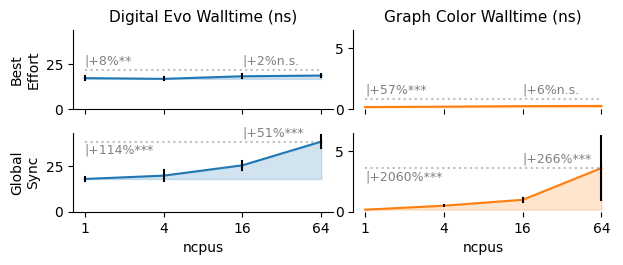

In [ ]:
with tp.teed(
    sns.relplot,
    data=filtered_procs,
    x="ncpus",
    y="Update Walltime (ms)",
    col="executable",
    hue="executable",
    row="asynchronicity mode",
    row_order=[3, 0],
    err_style=None,
    facet_kws=dict(margin_titles=True, sharey="col"),
    kind="line",
    legend=False,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:

    # adapted from https://github.com/mwaskom/seaborn/issues/2410#issuecomment-753474050
    for _i, (_ax, (_signif1, _signif2)) in enumerate(
        zip(
            _g.axes.flat,
            [
                ("**", "n.s."),
                ("***", "n.s."),
                ("***", "***"),
                ("***", "***"),
            ],
        )
    ):
        for line in _ax.lines:
            _x, _y = line.get_xydata().T
            _ax.fill_between(
                _x, _y.min(), _y, color=line.get_color(), alpha=0.2
            )

            _target_y = max(_y.max(), _y.min() * 1.3, _y.min() + 0.7)
            _ax.hlines(_target_y, 1, 64, color="gray", ls=":", alpha=0.5)

            _pct_change = ((_y[3] - _y[0]) / abs(_y[0])) * 100
            _va = {True: "bottom", False: "top"}[
                _target_y < np.mean(_ax.get_ylim())
            ]
            _ax.text(
                x=1,
                y=_target_y
                + np.ptp(_ax.get_ylim())
                * {"bottom": 0.05, "top": -0.05}[_va],
                s=f"|+{_pct_change:.0f}%{_signif1}",
                alpha=1.0,
                color="gray",
                ha="left",
                fontsize=9,
                va=_va,
            )

            _pct_change = ((_y[3] - _y[2]) / abs(_y[2])) * 100
            _va = "bottom"
            # _ax.hlines(_target_y + np.ptp(_ax.get_ylim()) * 0, 16, 64, color="beige", ls="--")
            _ax.text(
                x=16,
                y=_target_y
                + np.ptp(_ax.get_ylim())
                * {"bottom": 0.05, "top": -0.05}[_va],
                s=f"|+{_pct_change:.0f}%{_signif2}",
                alpha=1.0,
                color="gray",
                ha="left",
                fontsize=9,
                va=_va,
            )

    _g.map_dataframe(
        sns.lineplot,
        x="ncpus",
        y="Update Walltime (ms)",
        color="k",
        errorbar="sd",
        err_style="bars",
        legend=False,
        lw=0,
    )

    _g.set(ylim=(0, None))
    _g.set(xscale="log")
    _g.figure.set_size_inches(6, 2)
    _g.set_titles(col_template="{col_name}", row_template="")
    plt.subplots_adjust(hspace=0.3)

    for i, _ax in enumerate(_g.axes.flat):
        _ax.minorticks_off()
        _ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
        _ax.set_xticks([1, 4, 16, 64])
        if i % 2 != 0:
            sns.despine(ax=_ax, bottom=True)
        if i < 2:
            _ax.set_title(
                {
                    0: "Digital Evo Walltime (ns)",
                    1: "Graph Color Walltime (ns)",
                }[i],
                fontsize=11,
            )

    _g.axes[0, 0].set_ylabel("Best\nEffort")
    _g.axes[1, 0].set_ylabel("Global\nSync")

In [ ]:
_res = []
for (_mode, _exec), _group in filtered_procs.groupby(
    ["asynchronicity mode", "executable"]
):
    _g1, _g2 = (
        _group.loc[_group["ncpus"] == 1, "conflicts per cpu"],
        _group.loc[_group["ncpus"] == 64, "conflicts per cpu"],
    )

    _res.append(
        {
            "mode": _mode,
            "exec": _exec,
            "n": len(_group),
            "%": 100 * (_g2.mean() / _g1.mean() - 1),
            **dict(
                zip(
                    ["wstat", "p"],
                    scipy_stats.wilcoxon(_g1, _g2, alternative="less"),
                )
            ),
            **dict(zip(["delta", "interp"], cliffs_delta(_g1, _g2))),
        },
    )

pd.DataFrame(_res)

,mode,exec,n,%,wstat,p,delta,interp
0,0,channel_selection,40,454.331140,0.0,0.000977,-1.0,large
1,0,dishtiny,40,NaN,NaN,NaN,-1.0,large
2,3,channel_selection,40,31.054687,13.0,0.080078,-0.5,large
3,3,dishtiny,40,NaN,NaN,NaN,-1.0,large


In [ ]:
_res = []
for (_mode, _exec), _group in filtered_procs.groupby(
    ["asynchronicity mode", "executable"]
):
    _g1, _g2 = (
        _group.loc[_group["ncpus"] == 16, "conflicts per cpu"],
        _group.loc[_group["ncpus"] == 64, "conflicts per cpu"],
    )

    _res.append(
        {
            "mode": _mode,
            "exec": _exec,
            "n": len(_group),
            "%": 100 * (_g2.mean() / _g1.mean() - 1),
            **dict(
                zip(
                    ["wstat", "p"],
                    scipy_stats.wilcoxon(_g1, _g2, alternative="less"),
                )
            ),
            **dict(zip(["delta", "interp"], cliffs_delta(_g1, _g2))),
        },
    )

pd.DataFrame(_res)

,mode,exec,n,%,wstat,p,delta,interp
0,0,channel_selection,40,84.104151,0.0,0.000977,-0.84,large
1,0,dishtiny,40,NaN,NaN,NaN,-1.00,large
2,3,channel_selection,40,0.902256,24.0,0.384766,-0.17,small
3,3,dishtiny,40,NaN,NaN,NaN,-1.00,large


teeplots/2026-05-16-perf-quality/col=executable+hue=executable+kind=line+row=asynchronicity-mode+viz=relplot+x=ncpus+y=conflicts-per-cpu+ext=.pdf
teeplots/2026-05-16-perf-quality/col=executable+hue=executable+kind=line+row=asynchronicity-mode+viz=relplot+x=ncpus+y=conflicts-per-cpu+ext=.png


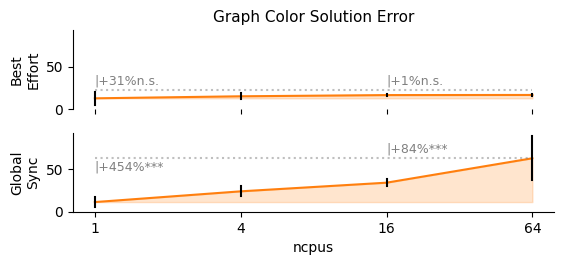

In [ ]:
with tp.teed(
    sns.relplot,
    data=filtered_procs,
    x="ncpus",
    y="conflicts per cpu",
    col="executable",
    col_order=["channel_selection"],
    hue="executable",
    row="asynchronicity mode",
    row_order=[3, 0],
    err_style=None,
    facet_kws=dict(margin_titles=True, sharey="col"),
    kind="line",
    legend=False,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:

    # adapted from https://github.com/mwaskom/seaborn/issues/2410#issuecomment-753474050
    for _i, (_ax, (_signif1, _signif2)) in enumerate(
        zip(_g.axes.flat, [("n.s.", "n.s."), ("***", "***")])
    ):
        for _line in _ax.lines:
            _x, _y = _line.get_xydata().T
            _ax.fill_between(
                _x, _y.min(), _y, color=_line.get_color(), alpha=0.2
            )

            _target_y = max(_y.max(), _y.min() + 10)
            _ax.hlines(_target_y, 1, 64, color="gray", ls=":", alpha=0.5)

            _pct_change = ((_y[3] - _y[0]) / abs(_y[0])) * 100
            _va = {True: "bottom", False: "top"}[
                _target_y < np.mean(_ax.get_ylim())
            ]
            _ax.text(
                x=1,
                y=_target_y
                + np.ptp(_ax.get_ylim())
                * {"bottom": 0.05, "top": -0.05}[_va],
                s=f"|+{_pct_change:.0f}%{_signif1}",
                alpha=1.0,
                color="gray",
                ha="left",
                fontsize=9,
                va=_va,
            )

            _pct_change = ((_y[3] - _y[2]) / abs(_y[2])) * 100
            _va = "bottom"
            # _ax.hlines(target_y + np.ptp(_ax.get_ylim()) * 0, 16, 64, color="beige", ls="--")
            _ax.text(
                x=16,
                y=_target_y
                + np.ptp(_ax.get_ylim())
                * {"bottom": 0.05, "top": -0.05}[_va],
                s=f"|+{_pct_change:.0f}%{_signif2}",
                alpha=1.0,
                color="gray",
                ha="left",
                fontsize=9,
                va=_va,
            )

    _g.map_dataframe(
        sns.lineplot,
        x="ncpus",
        y="conflicts per cpu",
        color="k",
        errorbar="sd",
        err_style="bars",
        legend=False,
        lw=0,
    )

    _g.set(ylim=(0, None))
    _g.set(xscale="log")
    _g.figure.set_size_inches(6, 2)
    _g.set_titles(col_template="{col_name}", row_template="")
    plt.subplots_adjust(hspace=0.3)

    for _i, _ax in enumerate(_g.axes.flat):
        _ax.minorticks_off()
        _ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
        _ax.set_xticks([1, 4, 16, 64])
        if _i == 0:
            sns.despine(ax=_ax, bottom=True)
        if _i == 0:
            _ax.set_title(
                {
                    0: "Graph Color Solution Error",
                }[_i],
                fontsize=11,
            )

    _g.axes[0, 0].set_ylabel("Best\nEffort")
    _g.axes[1, 0].set_ylabel("Global\nSync")

teeplots/2026-05-16-perf-quality/col=panel+hue=executable+kind=line+row=asynchronicity-mode+viz=perf-quality-combined+x=ncpus+y=value+ext=.pdf
teeplots/2026-05-16-perf-quality/col=panel+hue=executable+kind=line+row=asynchronicity-mode+viz=perf-quality-combined+x=ncpus+y=value+ext=.png


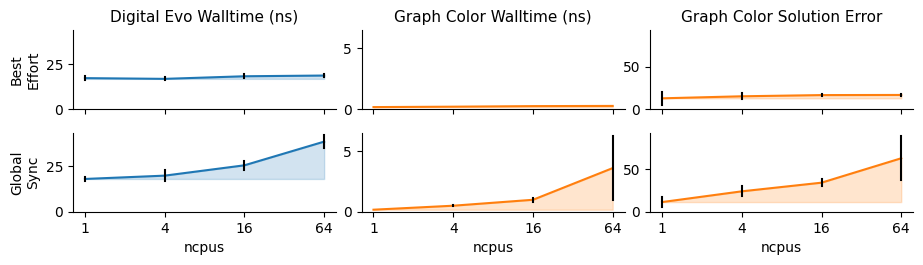

In [ ]:
_long = filtered_procs.melt(
    id_vars=["ncpus", "asynchronicity mode", "executable"],
    value_vars=["Update Walltime (ms)", "conflicts per cpu"],
    var_name="metric",
    value_name="value",
)
_panels = pd.DataFrame(
    [
        {
            "executable": "dishtiny",
            "metric": "Update Walltime (ms)",
            "panel": "Digital Evo Walltime (ns)",
        },
        {
            "executable": "channel_selection",
            "metric": "Update Walltime (ms)",
            "panel": "Graph Color Walltime (ns)",
        },
        {
            "executable": "channel_selection",
            "metric": "conflicts per cpu",
            "panel": "Graph Color Solution Error",
        },
    ]
)
_long = _long.merge(_panels, on=["executable", "metric"])

_col_order = [
    "Digital Evo Walltime (ns)",
    "Graph Color Walltime (ns)",
    "Graph Color Solution Error",
]

with tp.teed(
    sns.relplot,
    data=_long,
    x="ncpus",
    y="value",
    col="panel",
    col_order=_col_order,
    hue="executable",
    row="asynchronicity mode",
    row_order=[3, 0],
    err_style=None,
    facet_kws=dict(margin_titles=True, sharey="col"),
    kind="line",
    legend=False,
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_outattrs={"viz": "perf-quality-combined"},
    teeplot_outinclude=["viz"],
    teeplot_transparent=False,
) as _g:
    for _ax in _g.axes.flat:
        for _line in _ax.lines:
            _x, _y = _line.get_xydata().T
            _ax.fill_between(
                _x, _y.min(), _y, color=_line.get_color(), alpha=0.2
            )

    _g.map_dataframe(
        sns.lineplot,
        x="ncpus",
        y="value",
        color="k",
        errorbar="sd",
        err_style="bars",
        legend=False,
        lw=0,
    )

    _g.set(ylim=(0, None))
    _g.set(xscale="log")
    _g.figure.set_size_inches(9, 2)
    _g.set_titles(col_template="{col_name}", row_template="")
    plt.subplots_adjust(hspace=0.3)

    for _i, _ax in enumerate(_g.axes.flat):
        _ax.minorticks_off()
        _ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
        _ax.set_xticks([1, 4, 16, 64])
        _ax.set_ylabel("")

    for _ax in _g.axes[0, :]:
        _ax.set_title(_ax.get_title(), fontsize=11)

    _g.axes[0, 0].set_ylabel("Best\nEffort")
    _g.axes[1, 0].set_ylabel("Global\nSync")